# FS→DSA Final Analysis — Italy

This notebook guides through an analysis of Italy's MTP and the implications of policy-dependent potential output within the DSA. It can be run top-to-bottom without prior knowledge of the codebase. 

What the notebook will do:
- Load the FS and DSA models. For this excercise, only the supply block of the FS model is relevant: with no structural changes in taxation, the FS supply block is basically equivalent to the key trend equations in the PREM model.
- Enter MTP-informed baseline paths (SPB, potential growth & inflation)
    - Reasoning: We are asusming that the policies named in the MTP are consistent with the specified potential output and inflation paths. I.e.: The specified policy mix will lead to the specified macroeconomic conditions.
    - As GDP is endogenously calculated in the DSA based on PO and output gap, we do not use the (already endogenous) GDP path from the MTP as the baseline.
- Evaluate whether the SPB path from the MTP is still the binding SPB path given newly available data.
- Find the actual binding SPB path to form our baseline.
- Calibrate FS baseline to DSA.
- Run a policy scenario in FS and port it back to DSA.
- Compute the binding SPB path under different potential output assumptuons and compare baseline and scenario SPB target (fiscal space assessment)


## 1) Setup and imports


In [1]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Add the model directories to Python path
sys.path.append('model/fs')
sys.path.append('model/dsa/code/classes')

# Direct imports (no package structure)
from data_functions import load_and_process_data
from model_equations import build_model
from scenario_functions import initialize_model, run_scenario_analysis
from integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb
from StochasticDsaModelClass import StochasticDsaModel as DSA

# Analysis toggles
START, END = 2025, 2041

## 2) Import data
Load FS data and prepare the DSA model. 

In [2]:
IT = load_and_process_data(data_folder='data', sheet_name='Italy')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_IT = FS_model.insertModelVar(IT)
print('IT data shape:', IT.shape)

# set output gap mechanism in private investment = 0 as we dont assume this effect in PREM yet (all other variables affecting private investment dont change, so no need to adjust them)
data_IT.loc[:, 'LAMBDA_IQ_M_4'] = 0

dsa_it = DSA(country='ITA', start_year=2024, end_year=2041, adjustment_period=7, adjustment_start_year=2025, fiscal_multiplier_type='ec')
dsa_it.project()  # seed baseline arrays
df_it = dsa_it.df(all=True)

IT data shape: (84, 223)


## 3) Specify MTP paths (SPB, potential growth, inflation) and policy measures
The dictionaries below can be edited to specify different assumptions.
- SPB: level path (% of GDP)
- rg_pot: potential GDP growth (percent)
- pi: GDP deflator inflation (percent); available only up to 2029/2031 — we auto-align later years


In [3]:
years_full = list(range(dsa_it.start_year, dsa_it.end_year + 1))

# --- SPB level path from MTP, constant after ---
mtfp_spb_points = {
    2024: -0.5, 2025: 0, 2026: 0.6, 2027: 1.1, 2028: 1.6,
    2029: 2.2, 2030: 2.7, 2031: 3.2
}
mtfp_spb = pd.Series(mtfp_spb_points).reindex(years_full).interpolate().ffill().bfill()

# --- Potential GDP growth anchors constant after ---
mtfp_rg_pot_points = {
    2025: 0.6, 2026: 0.6, 2027: 0.5, 2028: 0.5, 2029: 0.5, 2030: 0.5, 2031: 0.5
}
mtfp_rg_pot = pd.Series(mtfp_rg_pot_points).reindex(years_full).interpolate().ffill().bfill()

# --- Inflation ---
mtfp_pi_points = {
    2025: 2.1, 2026: 2.0, 2027: 1.8, 2028: 2.0, 2029: 2.0, 2030: 2.1, 2031: 2.2, 2032: 2.3, 2033: 2.4, 2034: 2.4, 2035: 2.4, 2036: 2.3, 2037: 2.3, 2038: 2.3, 2039: 2.3, 2040: 2.3, 2041: 2.2
}


In [4]:
# Apply your MTP inflation and potential growth assumptions
mtp_anchors = {
    'rg_pot': pd.Series(mtfp_rg_pot),  # Potential growth
    'pi': mtfp_pi_points,              # Inflation path
}

# Convert your SPB level path to steps directly
a0 = dsa_it.adjustment_start  # This is 1 (2025)
a1 = dsa_it.adjustment_end    # This is 7 (2031)
years = np.arange(dsa_it.start_year, dsa_it.end_year + 1)  # [2024, 2025, ..., 2045]

# Get your SPB levels aligned to model years
spb_full = mtfp_spb.reindex(years).to_numpy()

# Calculate steps for adjustment period only
spb_steps = np.zeros(dsa_it.adjustment_period)  # Array of 7 zeros
for t in range(a0, a1 + 1):  # t goes from 1 to 7
    spb_steps[t - a0] = spb_full[t] - spb_full[t - 1]

print(f"SPB steps: {spb_steps}")
print(f"SPB levels: {spb_full[1:8]}")  # Show the levels for 2025-2031


SPB steps: [0.5 0.6 0.5 0.5 0.6 0.5 0.5]
SPB levels: [0.  0.6 1.1 1.6 2.2 2.7 3.2]


## 4) Initialise baseline

Project the debt ratio with the planned policies, assuming that they will lead to the specified potential output, SPB, and inflation changes/levels specified in the plan.

In [6]:
dsa_it.spb_bca[0] = -0.5
dsa_it.spb[0] = -0.5
apply_mtp_anchors_to_dsa(dsa_it, anchors=mtp_anchors, inplace=True)
dsa_it.growth_driven_preclosure = False
dsa_it.project(spb_steps=spb_steps)
df_it = dsa_it.df(all=True)


In [8]:
dsa_bl_opt = copy.deepcopy(dsa_it)
dsa_bl_opt.find_spb_binding(print_results=True, debt_safeguard=True)
df_bl_opt = dsa_bl_opt.df(all=True)
print(f"SPB: {dsa_it.spb_bca[7]:.2f}% vs Binding: {dsa_bl_opt.binding_spb_target:.2f}%")

                  Model Params                             SPB Targets       
================================================     ========================
country                                      ITA     main_adjustment    2.291
adjustment period                              7     lower_spb          2.760
adjustment start                            2025     financial_stress   2.508
shock frequency                        quarterly     adverse_r_g        3.359
stochastic period                      2032-2037     deficit_reduction  2.771
estimation                                normal     stochastic         2.363
bond level data                            False     debt_safeguard     3.453
safeguards         EDP, debt, deficit_resilience     binding            3.453
================================================     ========================

                                Binding Params                               
spb_steps                     0.565, 0.565, 0.565, 0.565, 0.565

In [9]:
# Extract rg_pot and pi series from dsa_bl_opt
rg = pd.Series(dsa_bl_opt.rg, index=years, name='rg')
rg_pot = pd.Series(dsa_bl_opt.rg_pot, index=years, name='rg_pot')
pi = pd.Series(dsa_bl_opt.pi, index=years, name='pi')

bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

In [10]:

baseline_IT = initialize_model(
    data=data_IT, 
    model_class=FS_model, 
    start=START, 
    end=END,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  # This should use your DSA model
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(dsa_bl_opt),  # Use the binding DSA model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

## 5) Scenario analysis
Estimate the impact of the policy measures in the FS model, then port the scenario potential into DSA for comparison.

In [11]:
measures = [
    # Measure 1: Active Labour market policies → EPS_LP
    { 'var': 'EPS_LP', 'values': [0.0000, 0.22557, 0.22557, 0.22557, 0.22557], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
    
]

In [12]:
scenario_IT = run_scenario_analysis(
    baseline_result=baseline_IT, model_class=FS_model,
    scenario_shocks=measures, scenario_name='IT_policy', allow_fixed_shocks=True
)

,Period 1,Period 2,Period 3,Period 4,Period 5
EPS_LP,0.0,0.22557,0.22557,0.22557,0.22557


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [14]:
# Calculate smoothed growth rates for Italy (IT) in two periods: 2024-2026 and 2027-2041

# --- 2024 to 2026 ---
start_2024 = scenario_IT.loc[2024, 'Y_STAR']
end_2026 = scenario_IT.loc[2026, 'Y_STAR']

growth_factor_24_26 = end_2026 / start_2024
years_24_26 = 2026 - 2024  # 2 years
const_growth_rate_24_26 = (growth_factor_24_26 ** (1/years_24_26)) - 1

# Create smoothed Y_STAR series for 2024-2026
scenario_IT['Y_STAR_smooth_24_26'] = scenario_IT['Y_STAR'].copy()
scenario_IT.loc[2024, 'Y_STAR_smooth_24_26'] = start_2024
for year in range(2025, 2027):
    scenario_IT.loc[year, 'Y_STAR_smooth_24_26'] = start_2024 * ((1 + const_growth_rate_24_26) ** (year - 2024))
scenario_IT['Y_STAR_growth_smooth_24_26'] = scenario_IT['Y_STAR_smooth_24_26'].pct_change() * 100

# --- 2027 to 2041 ---
start_2026 = scenario_IT.loc[2026, 'Y_STAR']
end_2041 = scenario_IT.loc[2041, 'Y_STAR']

growth_factor_27_41 = end_2041 / start_2026
years_27_41 = 2041 - 2026  # 15 years
const_growth_rate_27_41 = (growth_factor_27_41 ** (1/years_27_41)) - 1

# Create smoothed Y_STAR series for 2027-2041
scenario_IT['Y_STAR_smooth_27_41'] = scenario_IT['Y_STAR'].copy()
scenario_IT.loc[2026, 'Y_STAR_smooth_27_41'] = start_2026
for year in range(2027, 2042):
    scenario_IT.loc[year, 'Y_STAR_smooth_27_41'] = start_2026 * ((1 + const_growth_rate_27_41) ** (year - 2026))
scenario_IT['Y_STAR_growth_smooth_27_41'] = scenario_IT['Y_STAR_smooth_27_41'].pct_change() * 100

print("Italy Scenario 4 - Potential Output Growth Rates")
print("=" * 50)
print("2024 to 2026:")
print(f"  Total growth factor: {growth_factor_24_26:.4f}")
print(f"  Constant annual growth rate: {const_growth_rate_24_26*100:.2f}%")
print(f"  Growth from 2024 to 2026: {(growth_factor_24_26-1)*100:.2f}%")
print("-" * 50)
print("2027 to 2041:")
print(f"  Total growth factor: {growth_factor_27_41:.4f}")
print(f"  Constant annual growth rate: {const_growth_rate_27_41*100:.2f}%")
print(f"  Growth from 2026 to 2041: {(growth_factor_27_41-1)*100:.2f}%")

Italy Scenario 4 - Potential Output Growth Rates
2024 to 2026:
  Total growth factor: 1.0144
  Constant annual growth rate: 0.72%
  Growth from 2024 to 2026: 1.44%
--------------------------------------------------
2027 to 2041:
  Total growth factor: 1.0864
  Constant annual growth rate: 0.55%
  Growth from 2026 to 2041: 8.64%


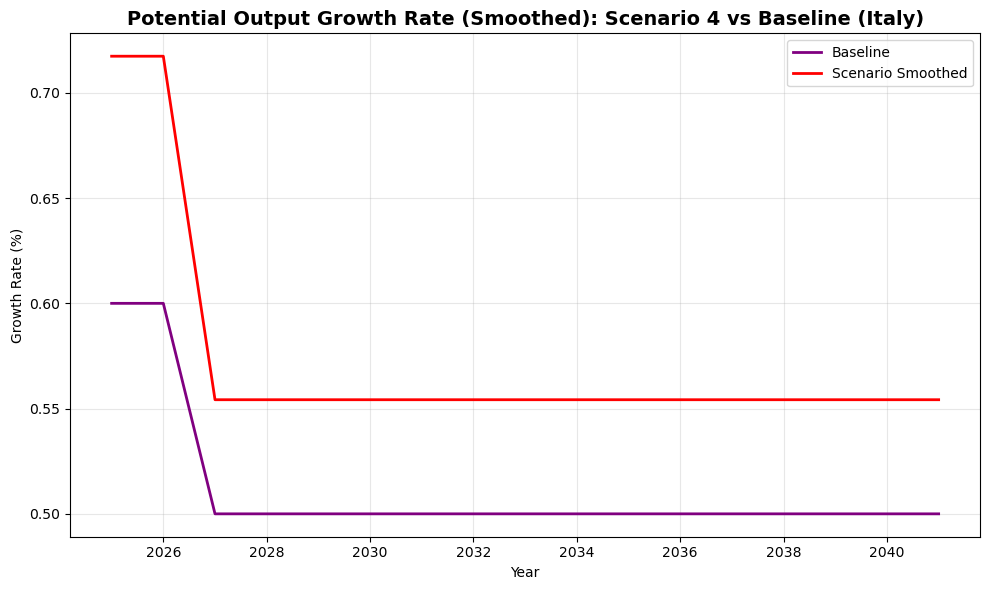

In [15]:

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_title('Potential Output Growth Rate (Smoothed): Scenario 4 vs Baseline (Italy)', fontsize=14, fontweight='bold')

years_growth = range(2025, 2042)  # growth rates start from 2025

# Plot baseline growth rate
ax.plot(
    years_growth,
    baseline_IT.loc[years_growth, 'G_Y_STAR'],
    color='purple', linestyle='-', linewidth=2,
    label='Baseline'
)

# Plot scenario smoothed growth rate (piecewise: 2025-2026 and 2027-2041)
ax.plot(
    years_growth,
    [scenario_IT.loc[y, 'Y_STAR_growth_smooth_24_26'] if y <= 2026 else scenario_IT.loc[y, 'Y_STAR_growth_smooth_27_41'] for y in years_growth],
    color='red', linestyle='-', linewidth=2,
    label='Scenario Smoothed'
)

ax.set_xlabel('Year')
ax.set_ylabel('Growth Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Create DSA model
dsa_scenario = copy.deepcopy(dsa_it)

# Define growth periods for Italy with two different levels
italy_growth_periods = [
    {'start_year': 2025, 'end_year': 2028, 'growth_rate': const_growth_rate_24_26*100},
    {'start_year': 2029, 'end_year': 2041, 'growth_rate': const_growth_rate_27_41*100}
]

# Apply potential output from FS scenarios to DSA models with two-level smoothed growth
apply_fs_potential_to_dsa(dsa_scenario, fs_df=scenario_IT, inplace=True, 
                         growth_periods=italy_growth_periods)

# Now run DSA projections for Italy
dsa_scenario.project(spb_steps=spb_steps)



## 6) Optimal path & fiscal space
Compare binding SPB paths for baseline and scenario.

In [17]:
dsa_sce_opt = copy.deepcopy(dsa_scenario)
dsa_sce_opt.find_spb_binding(
        print_results=False
    )
df_sce_opt = dsa_sce_opt.df(all=True)
    
sce_opt_tgt = float(dsa_sce_opt.binding_spb_target)
sce_opt_steps = dsa_sce_opt.binding_parameter_dict['spb_steps'].copy()

print(f"Baseline Binding: {dsa_bl_opt.spb_bca[7]:.4f}% vs Scenario Binding: {dsa_sce_opt.binding_spb_target:.4f}%")


Baseline Binding: 3.4531% vs Scenario Binding: 3.3299%


In [18]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for Italy

years_it = range(2024, 2042)  # 2025-2041 for Italy

# Helper function to get EUR values (Italy)
def get_eur_values_it(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (Italy)
def get_pct_values_it(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for Italy, including debt ratio and potential output growth
results_it = {
    'Year': years_it,
    'SPB_Baseline_%': [get_pct_values_it(dsa_bl_opt, y, 'spb_bca') for y in years_it],
    'SPB_Scenario_%': [get_pct_values_it(dsa_sce_opt, y, 'spb_bca') for y in years_it],
    'SPB_Baseline_EUR': [get_eur_values_it(dsa_bl_opt, y, 'spb_bca') for y in years_it],
    'SPB_Scenario_EUR': [get_eur_values_it(dsa_sce_opt, y, 'spb_bca') for y in years_it],
    'Debt_Baseline_%': [get_pct_values_it(dsa_bl_opt, y, 'd') for y in years_it],
    'Debt_Scenario_%': [get_pct_values_it(dsa_sce_opt, y, 'd') for y in years_it],
    'PotOut_Growth_Baseline_%': [get_pct_values_it(dsa_bl_opt, y, 'rg_pot') for y in years_it],
    'PotOut_Growth_Scenario_%': [get_pct_values_it(dsa_sce_opt, y, 'rg_pot') for y in years_it],
}

# Create DataFrame for Italy
comparison_df_it = pd.DataFrame(results_it)

# Calculate differences for Italy
comparison_df_it['SPB_Diff_%'] = comparison_df_it['SPB_Scenario_%'] - comparison_df_it['SPB_Baseline_%']
comparison_df_it['SPB_Diff_EUR'] = comparison_df_it['SPB_Scenario_EUR'] - comparison_df_it['SPB_Baseline_EUR']
comparison_df_it['Debt_Diff_%'] = comparison_df_it['Debt_Scenario_%'] - comparison_df_it['Debt_Baseline_%']
comparison_df_it['PotOut_Growth_Diff_%'] = comparison_df_it['PotOut_Growth_Scenario_%'] - comparison_df_it['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison (Italy):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_it = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_it = comparison_df_it.copy()
for col in eur_cols_it:
    comparison_df_display_it[col] = comparison_df_display_it[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_it.round(2))

SPB, Debt Ratio, and Potential Output Growth Comparison (Italy):


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-0.50,-0.50,"-10,960,910,000","-10,960,910,000",135.33,135.33,0.6,1.27,0.00,0,0.00,0.67
1,2025,0.06,0.05,"1,456,999,098","1,062,198,973",137.05,136.88,0.6,0.72,-0.02,"-394,800,125",-0.17,0.12
2,2026,0.63,0.59,"14,481,560,043","13,706,577,943",139.38,139.06,0.6,0.72,-0.04,"-774,982,100",-0.32,0.12
3,2027,1.19,1.14,"27,939,358,156","26,831,652,441",140.16,139.56,0.5,0.72,-0.05,"-1,107,705,715",-0.60,0.22
4,2028,1.76,1.69,"42,014,725,354","40,615,161,982",140.20,139.33,0.5,0.72,-0.07,"-1,399,563,372",-0.87,0.22
5,2029,2.32,2.24,"56,743,918,182","55,007,898,523",139.78,138.89,0.5,0.55,-0.09,"-1,736,019,659",-0.89,0.05
6,2030,2.89,2.78,"72,245,524,009","70,169,807,382",138.78,137.89,0.5,0.55,-0.11,"-2,075,716,626",-0.89,0.05
7,2031,3.45,3.33,"88,605,497,687","86,186,069,442",137.20,136.33,0.5,0.55,-0.12,"-2,419,428,245",-0.87,0.05
8,2032,3.45,3.33,"91,413,294,414","88,953,916,912",134.97,134.15,0.5,0.55,-0.12,"-2,459,377,502",-0.82,0.05
9,2033,3.45,3.33,"94,401,123,647","91,899,375,736",132.66,131.90,0.5,0.55,-0.12,"-2,501,747,911",-0.76,0.05


In [19]:
# Save the comparison dataframe for Italy
#comparison_df_it.to_excel('Italy_Results_v2.xlsx', index=False)
#print("DataFrame saved as 'Italy_Results_v2.xlsx'")